In [ ]:
from importlib import reload
import torch
import numpy as np
import time
import copy
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main,synthetic_data
CUDA_LAUNCH_BLOCKING=1
cupy_device=2
def single_S(y,x_left,x_right,y_below,y_upper,center,r): #单个源
    return np.exp(-300*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))

def ana_S(y,x_left,x_right,y_below,y_upper,center,r):
    y0=y[:,0]
    y1=y[:,1]
    return 1.1*np.exp(-200*((y0-0.01)**2+(y1-0.12)**2))-100*(y1**2-y0**2)*np.exp(-90*(y0**2+y1**2))




cuda:2


In [10]:
reload(mea_2D)
reload(generate_data2)
reload(org_m)
reload(grid_cell)
reload(net_2D_fix2)


<module 'net_2D_fix2' from '/data5/store1/hxw/反源/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/有限孔径/./main_code2/net_2D_fix2.py'>

## 1

In [3]:
a = 0.6  # V_0 = [-a, a] × [-a, a]
R = 0.5  # Radius of measurement circle
rho = 0.6  # Radius for artificial Cauchy data
lam = 1e-3  # Parameter λ
k_star = lam * 2*np.pi / a #k*
noise_level=0.05

N = 2 * int(noise_level**(-1/3)+1) #N

l = []
for i in range(N+1):        # i from 0 to 6
    for j in range(i, N+1): # j from i to 6
        l.append([i, j])

vector_l=np.array(l)
norm_l=np.linalg.norm(vector_l,axis=1)
norm_l[0]=10**(-3)
K_N=10*np.pi/3*norm_l
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
number_gene=200
eps=0.05
batch_number_rec_mea,mea=2,1
kk=K_N

In [47]:
reload(generate_data2)

<module 'generate_data2' from '/data5/store1/hxw/反源/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/2d_inverse_source_Kernet_DiriNeu_test2/./main_code3/generate_data2.py'>

## 生成数据

In [30]:
reload(synthetic_data)

<module 'synthetic_data' from '/data5/store1/hxw/反源/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/2d_inverse_source_Kernet_DiriNeu_test2/./main_code3/synthetic_data.py'>

In [10]:
b_n=100
N_m=100
N_m_inv=400
points_b_R=mea_2D.p_b_circle(alpha=1,radius=0.5,n=b_n,temp=False) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
number_gene=200
eps=0.05
batch_number_rec_mea,mea=2,1
rho=0.6
S_int_true1, F_mea_b_R, F_mea_db_R= generate_data2.boundary_data_rec(kk, number_gene, points_b_R, ana_S,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],eps,mea,batch_number_rec_mea,device,cupy_device)
points_b_rho=mea_2D.p_b_circle(alpha=1,radius=rho,n=N_m_inv,temp=False) #在边界Γ处收集数据
n_trun=60
v_rho,dv_rho=synthetic_data.dir_neu(N_m,N_m_inv,kk,R,rho,n_trun,F_mea_b_R) 
V_rho=org_m.F(v_rho,dv_rho) #没问题
R_m=20


In [11]:
Nx,Ny=1,1
Ix,Iy=1,1  #x方向网格点
nx,ny=100,100  #每个网格x方向的高斯点
cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b_rho) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份

In [9]:
V_rho.shape

(22400, 1)

In [12]:
import time #和随机种子密切相关！甚至影响收敛 可以这样：先进行预训练 可以帮助排除不好的随机种子 但是预训练也需要计算成本
import numpy as np
# np.random.seed(2)
# torch.manual_seed(2)
# torch.cuda.manual_seed_all(2)
torch.backends.cudnn.deterministic = True
M=3200
af="sin"   
R_m=20
models0 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,"sin",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)

In [14]:
10**(-1.8)

0.015848931924611134

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


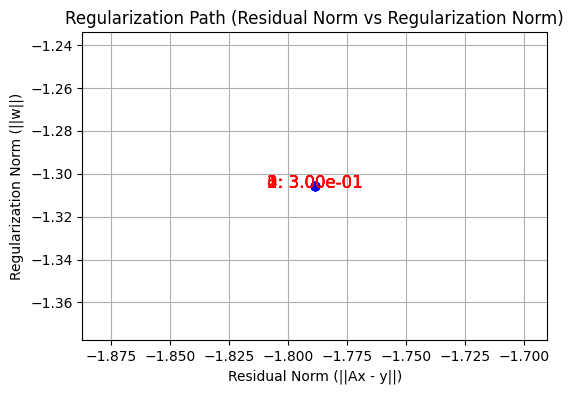

第 0 次迭代的train误差：
S_l_inf= 0.09861828316816623 S_L_2= 0.0014270407409253966 S_l_2= 0.013926707686024994
第 0 次迭代的泛化误差：
S_l_inf= 0.0673111157276432 S_L_2= 0.0009659067959216595 S_l_2= 0.006382626615796667


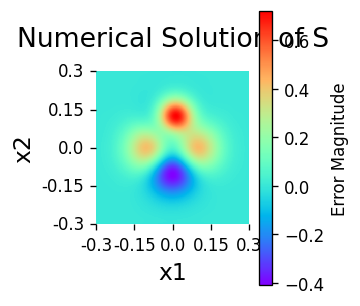

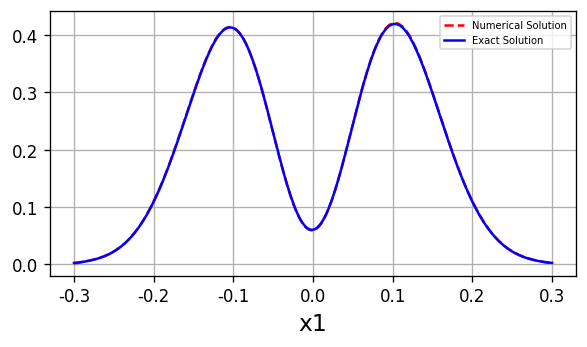

第 0 次自适应网格细分...
当前活跃网格数量: 1 ,标记细分网格数量: 1
成功细分了 1 个网格单元
最大指示器值: 4.176721 ,平均指示器值: 4.176721
Generating visualizations...
1. Plotting mesh comparison...


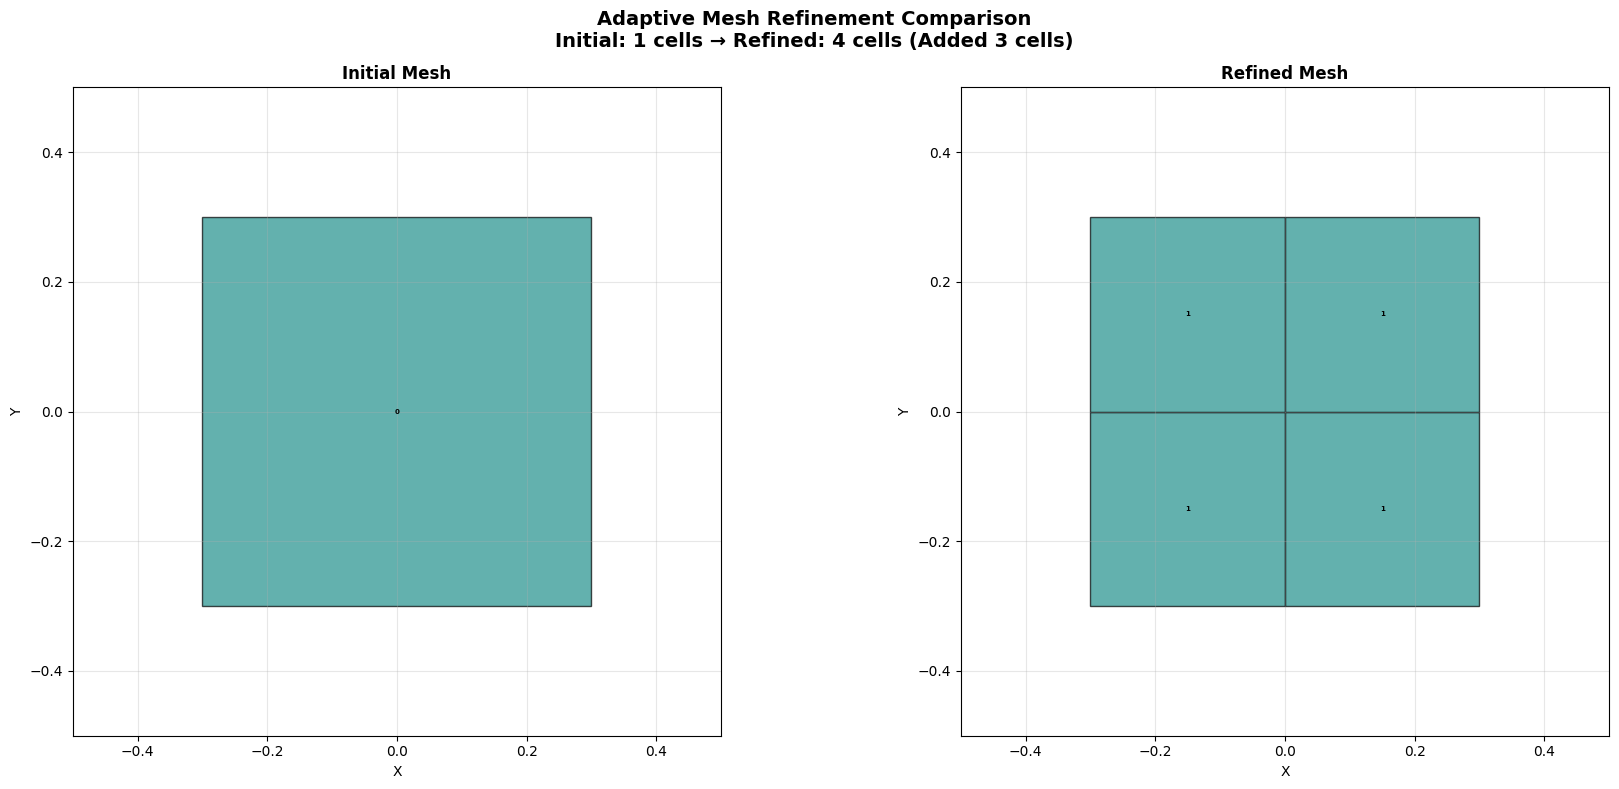

All visualizations completed!


In [13]:
delta=10**(-3)
lamb_regu=3*np.logspace(-1,-1,5)
Qx,Qy=150,150
iter_int=1
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store=main.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,V_rho,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],ana_S,points_b_rho,lamb_regu,Qx,Qy,device,cupy_device)

In [74]:
# 保存 models1 模型
torch.save(models0,f"./FM_IARFM/N_m=50/models0_55_3200_{point_number[-1]}_10-2.pth")


In [75]:
np.save("./FM_IARFM/N_m=50/S_num_store",S_num_store)


In [76]:
import pickle # 导入 pickle 模块
output_pickle_file = "./FM_IARFM/N_m=50/cells_store_last.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store[-1], f)